- Procedencia de los viajeros por años del 2015 al 2019

In [40]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [45]:

# ── 1. CARGA DE ARCHIVOS ──────────────────────────────────────────────────────

df_anual = pd.read_csv("../../data/clean_data_procedencia_07_04_2026.csv")



In [46]:
print(df_anual.columns)

Index(['tipo', 'origen', 'pais', 'periodo', 'total', 'level', 'year', 'month',
       'date', 'pais_final'],
      dtype='object')


In [56]:
excluir = [
    "No residentes en España",
    "Unión Europea 27 (sin España)",
    "Países africanos",
    "Resto del Mundo", "Resto de la U.E.", 
]

top_n = 10

# 1. Filtrar
df_filtrado = df_anual.loc[~df_anual["pais"].isin(excluir)]

# 2. AGRUPAR (esto es lo que te faltaba)
df_agregado = (
    df_filtrado
    .groupby(["year", "pais"], as_index=False)["total"]
    .sum()
)

# 3. Ordenar + TOP N
procedencia_limpia = (
    df_agregado
    .sort_values(["year", "total"], ascending=[True, False])
    .groupby("year")
    .head(top_n)
    .reset_index(drop=True)
)

display(procedencia_limpia)

,year,pais,total
0,2015,Residentes en España,157778502.0
1,2015,Reino Unido,61081904.0
2,2015,Alemania,53442979.0
3,2015,Francia,21976744.0
4,2015,Italia,11111239.0
5,2015,Países Bajos,9360321.0
6,2015,Bélgica,7772024.0
7,2015,Suecia,5700614.0
8,2015,Suiza,4752245.0
9,2015,Rusia,4560671.0


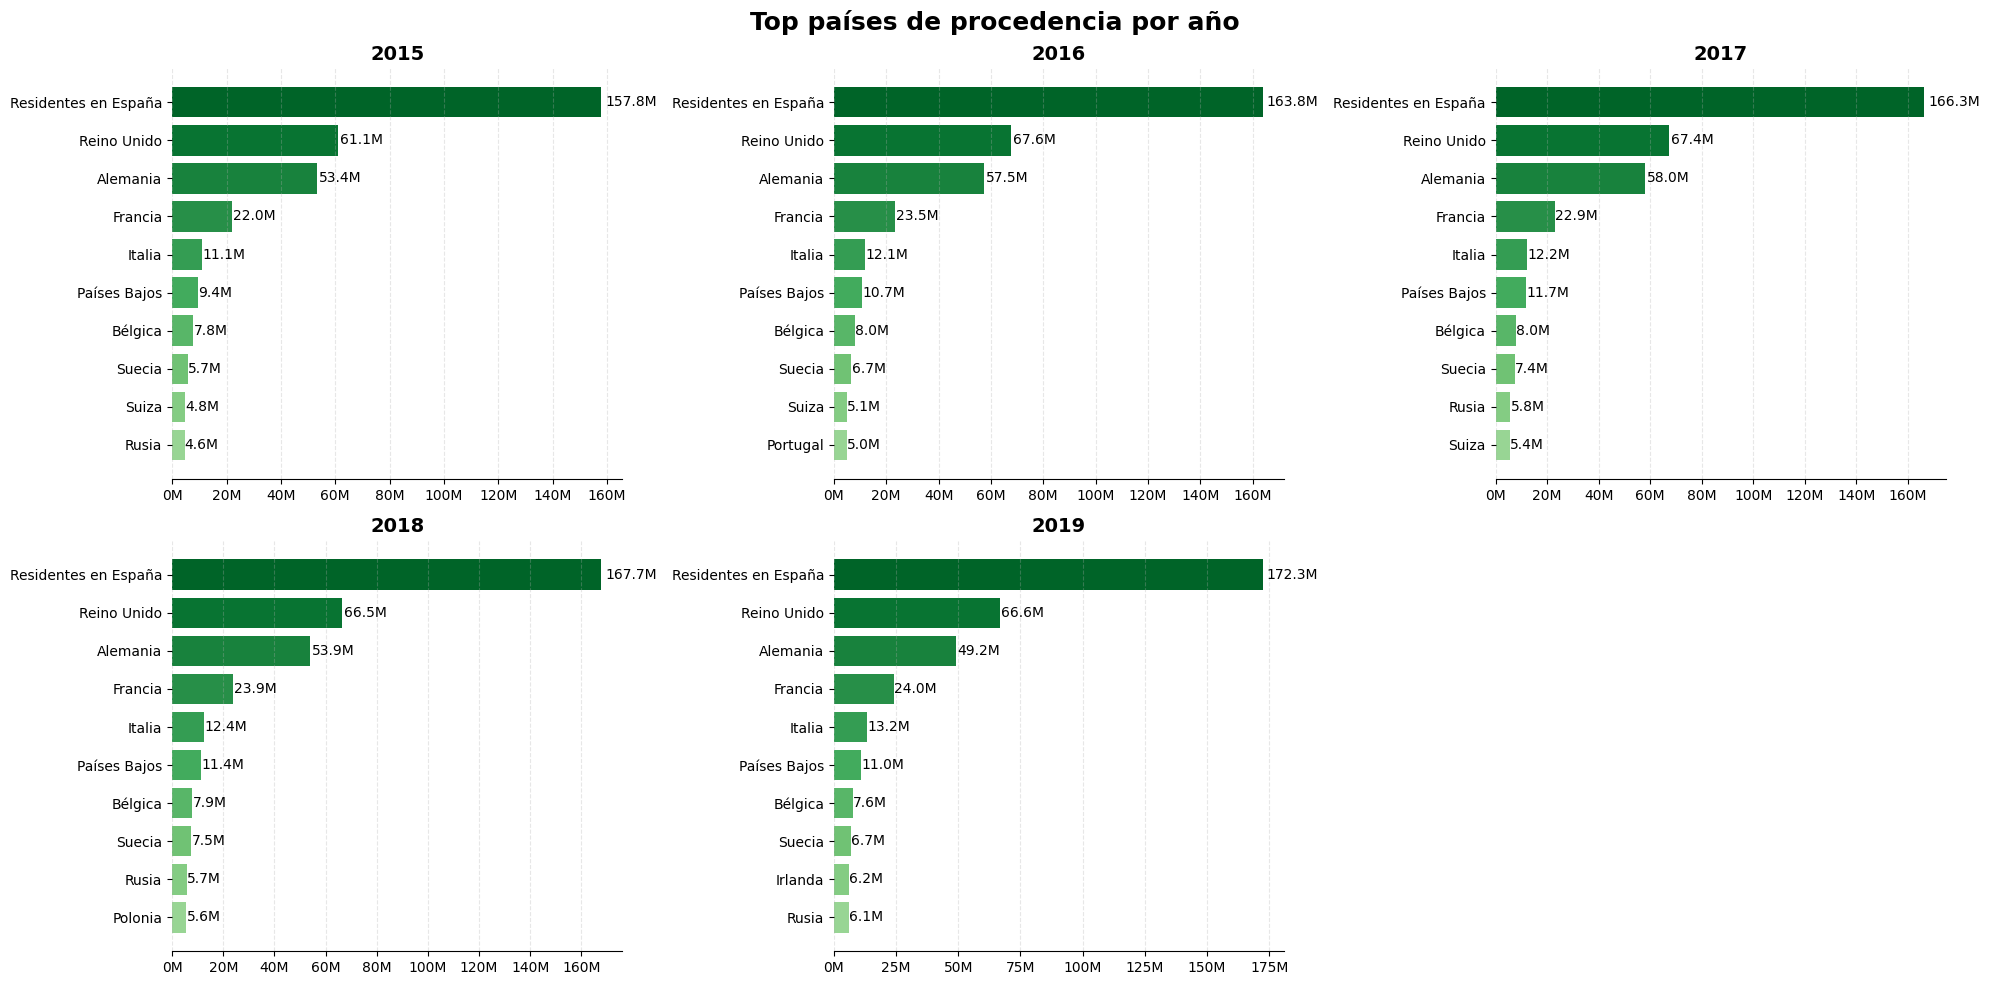

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

años = sorted(procedencia_limpia["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, año in enumerate(años):
    ax = axes[i]
    
    datos = (
        procedencia_limpia[procedencia_limpia["year"] == año]
        .sort_values("total", ascending=True)
    )
    
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(datos)))
    
    bars = ax.barh(datos["pais"], datos["total"], color=colors)
    
    for bar, val in zip(bars, datos["total"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(f"{año}", fontsize=14, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# Eliminar subplot vacío (el 6º)
fig.delaxes(axes[-1])

fig.suptitle(
    "Top países de procedencia por año",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("top_paises_grid.png", dpi=200, bbox_inches="tight")
plt.show()

In [61]:
df_ccaa_raw = pd.read_csv("../../data/clean_viajeros_07_04_2026.csv")

In [63]:
df = df_ccaa_raw.copy()

df["pais_origen"] = df["pais_origen"].str.strip().str.lower()
df["ccaa"] = df["ccaa"].str.strip()

In [64]:
excluir = [
    "no residentes en españa",
    "unión europea 27 (sin españa)",
    "países africanos",
    "resto del Mundo", "Resto de la U.E."
]

df_filtrado = df.loc[~df["pais_origen"].isin(excluir)]

In [65]:
df_ccaa = (
    df_filtrado
    .groupby(["ccaa", "pais_origen"], as_index=False)["qty_viajeros"]
    .sum()
)

In [66]:
top_n = 10

df_top = (
    df_ccaa
    .sort_values(["ccaa", "qty_viajeros"], ascending=[True, False])
    .groupby("ccaa")
    .head(top_n)
    .reset_index(drop=True)
)

In [67]:
print(df["ccaa"].unique())

['Andalucia' 'Islas Baleares' 'Cataluña' 'Comunidad Valenciana' 'Madrid']


In [70]:
ccaas_filtro = [
    "Andalucia",
    "Islas Baleares",
    "Cataluña",
    "Comunidad Valenciana",
    "Madrid"
]

df_top_filtrado = df_top[df_top["ccaa"].isin(ccaas_filtro)]

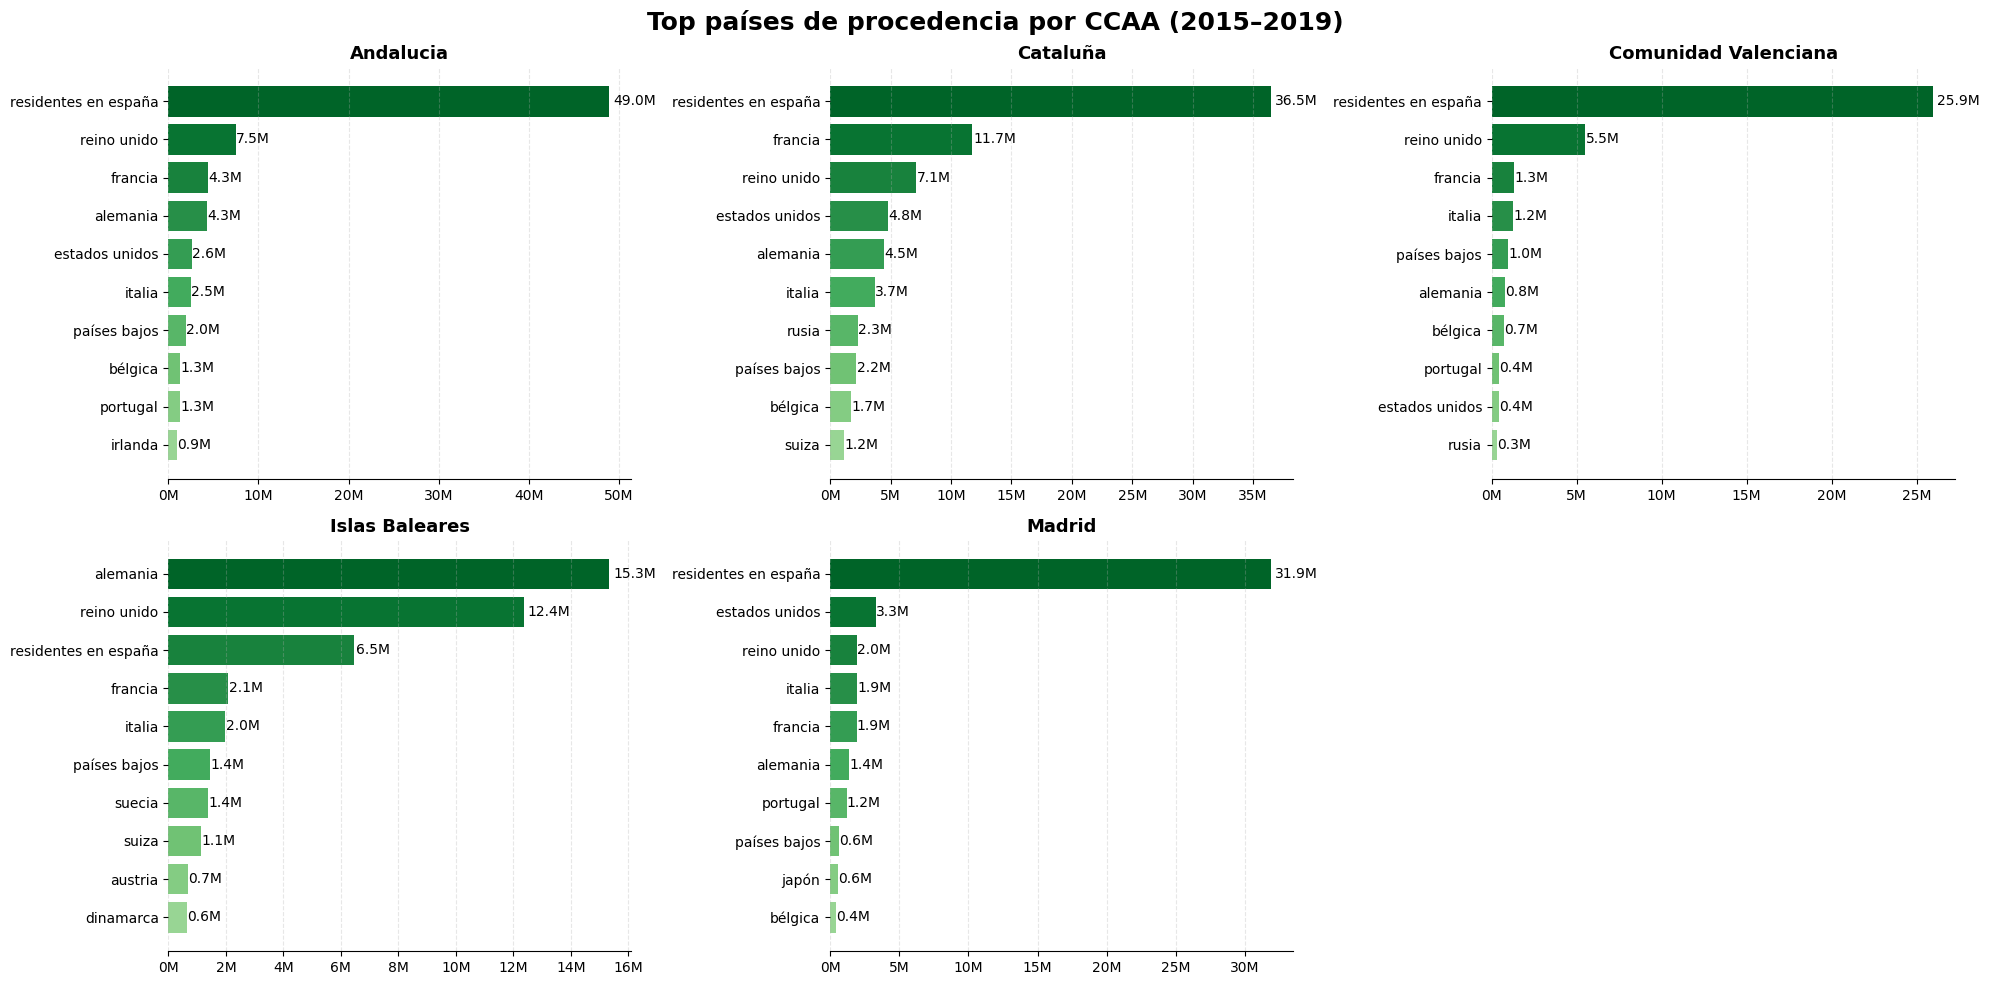

In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ccaas = sorted(df_top_filtrado["ccaa"].unique())

n_cols = 3
n_rows = -(-len(ccaas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["ccaa"] == ccaa]
        .sort_values("qty_viajeros", ascending=True)
    )
    
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(datos)))
    
    bars = ax.barh(datos["pais_origen"], datos["qty_viajeros"], color=colors)
    
    for bar, val in zip(bars, datos["qty_viajeros"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(ccaa, fontsize=13, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# eliminar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Top países de procedencia por CCAA (2015–2019)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("top_paises_ccaa.png", dpi=200, bbox_inches="tight")
plt.show()